In [ ]:
%pip install gymnasium torch matplotlib numpy

In [ ]:
import random
from collections import deque

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# Configuração de semente para reprodutibilidade dos testes
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

  Using cached gymnasium-1.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached farama_notifications-0.0.6-py3-none-any.whl.metadata (729 bytes)
  Using cached filelock-3.32.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached gymnasium-1.3.0-py3-none-any.whl (953 kB)
   ---------------------------------------- 0.0/122.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.0 MB 1.3 MB/s eta 0:01:36
   ---------------------------------------- 0.1/122.0 MB 1.3 MB/s eta 0:01:33
   ---------------------------------------- 0.2/122.0

In [3]:
class QNetwork(nn.Module):

  def __init__(self, state_dim, action_dim):
    super(QNetwork, self).__init__()
    self.fc = nn.Sequential(
        nn.Linear(state_dim, 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, action_dim),
    )

  def forward(self, x):
    return self.fc(x)

In [4]:
class ReplayBuffer:

  def __init__(self, capacity=10000):
    self.buffer = deque(maxlen=capacity)

  def push(self, state, action, reward, next_state, done):
    self.buffer.append((state, action, reward, next_state, done))

  def sample(self, batch_size):
    state, action, reward, next_state, done = zip(
        *random.sample(self.buffer, batch_size)
    )
    return (
        torch.FloatTensor(np.array(state)),
        torch.LongTensor(action),
        torch.FloatTensor(reward),
        torch.FloatTensor(np.array(next_state)),
        torch.FloatTensor(done),
    )

  def __len__(self):
    return len(self.buffer)


class DQNAgent:

  def __init__(
      self,
      state_dim,
      action_dim,
      gamma=0.99,
      lr=1e-3,
      batch_size=64,
      epsilon_start=1.0,
      epsilon_end=0.01,
      epsilon_decay=0.995,
  ):
    self.action_dim = action_dim
    self.gamma = gamma
    self.batch_size = batch_size

    # Controle da Exploração (Epsilon-Greedy)
    self.epsilon = epsilon_start
    self.epsilon_end = epsilon_end
    self.epsilon_decay = epsilon_decay

    # Redes Neurais Principal e Alvo (Target Network)
    self.policy_net = QNetwork(state_dim, action_dim)
    self.target_net = QNetwork(state_dim, action_dim)
    self.target_net.load_state_dict(self.policy_net.state_dict())

    self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
    self.memory = ReplayBuffer()

  def select_action(self, state):
    if random.random() < self.epsilon:
      return random.randint(0, self.action_dim - 1)  # Exploração (Aleatório)

    state_t = torch.FloatTensor(state).unsqueeze(0)
    with torch.no_grad():
      q_values = self.policy_net(state_t)
    return torch.argmax(q_values).item()  # Explotação (Rede Neural)

  def train_step(self):
    if len(self.memory) < self.batch_size:
      return

    # Amostragem do Replay Buffer
    states, actions, rewards, next_states, dones = self.memory.sample(
        self.batch_size
    )

    # Q-Value atual predito pela rede principal
    q_values = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    # Q-Value futuro predito pela target network (Equação de Bellman)
    with torch.no_grad():
      max_next_q_values = self.target_net(next_states).max(1)[0]
      target_q_values = rewards + (1 - dones) * self.gamma * max_next_q_values

    # Perda do Erro Quadrático Médio (MSE)
    loss = nn.MSELoss()(q_values, target_q_values)

    self.optimizer.zero_grad()
    loss.backward()
    self.optimizer.step()

    # Decaimento do Epsilon
    self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

  def update_target_network(self):
    self.target_net.load_state_dict(self.policy_net.state_dict())

In [5]:
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

agent = DQNAgent(state_dim, action_dim)
episodes = 300
target_update_freq = 10
scores = []

print("Iniciando treinamento do DQN no CartPole-v1...\n")

for episode in range(1, episodes + 1):
  state, _ = env.reset(seed=SEED + episode)
  total_reward = 0
  done = False

  while not done:
    action = agent.select_action(state)
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    agent.memory.push(state, action, reward, next_state, float(done))
    agent.train_step()

    state = next_state
    total_reward += reward

  scores.append(total_reward)

  # Atualização periódica da Target Network
  if episode % target_update_freq == 0:
    agent.update_target_network()

  if episode % 20 == 0:
    avg_score = np.mean(scores[-20:])
    print(
        f"Episódio {episode}/{episodes} | Pontuação Média (Últimos 20):"
        f" {avg_score:.1f} | Epsilon: {agent.epsilon:.2f}"
    )

env.close()

Iniciando treinamento do DQN no CartPole-v1...

Episódio 20/300 | Pontuação Média (Últimos 20): 14.6 | Epsilon: 0.32
Episódio 40/300 | Pontuação Média (Últimos 20): 10.8 | Epsilon: 0.11
Episódio 60/300 | Pontuação Média (Últimos 20): 81.2 | Epsilon: 0.01
Episódio 80/300 | Pontuação Média (Últimos 20): 208.3 | Epsilon: 0.01
Episódio 100/300 | Pontuação Média (Últimos 20): 199.6 | Epsilon: 0.01
Episódio 120/300 | Pontuação Média (Últimos 20): 165.5 | Epsilon: 0.01
Episódio 140/300 | Pontuação Média (Últimos 20): 213.5 | Epsilon: 0.01
Episódio 160/300 | Pontuação Média (Últimos 20): 173.8 | Epsilon: 0.01
Episódio 180/300 | Pontuação Média (Últimos 20): 251.9 | Epsilon: 0.01
Episódio 200/300 | Pontuação Média (Últimos 20): 319.2 | Epsilon: 0.01
Episódio 220/300 | Pontuação Média (Últimos 20): 271.6 | Epsilon: 0.01
Episódio 240/300 | Pontuação Média (Últimos 20): 240.5 | Epsilon: 0.01
Episódio 260/300 | Pontuação Média (Últimos 20): 310.9 | Epsilon: 0.01
Episódio 280/300 | Pontuação Média (

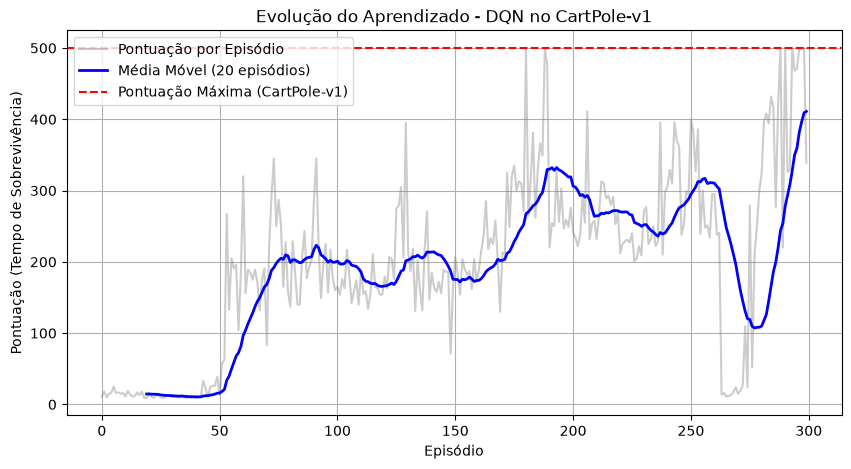

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(scores, label="Pontuação por Episódio", alpha=0.4, color="gray")

# Média móvel de 20 episódios
moving_avg = np.convolve(scores, np.ones(20) / 20, mode="valid")
plt.plot(
    range(19, len(scores)),
    moving_avg,
    label="Média Móvel (20 episódios)",
    color="blue",
    linewidth=2,
)

plt.axhline(
    y=500, color="r", linestyle="--", label="Pontuação Máxima (CartPole-v1)"
)
plt.title("Evolução do Aprendizado - DQN no CartPole-v1")
plt.xlabel("Episódio")
plt.ylabel("Pontuação (Tempo de Sobrevivência)")
plt.legend()
plt.grid(True)
plt.show()